# Notebook for parameter searching of parameter space for MCMC Model 
Created by MTH on 04/29/2025

This notebook is to explore sampling of the Sobol space to generate different runs of the MCMC model. 



Rough approach for the sampling approach: 
1. Create a sampling of the different Sobol space, with number of samples. This array will be n_samples, n_params. Therefore, the rows, the different columns will be rescaled based on the bound of the param. 
2. Read in the default parameter list into the dictionary structure as carried out previously. 
3. Honestly, probably best to create the full df, with the default parameters, then replace the columns as they are rescaled. 
4. The pandas write to csv should output the variables in the correct structure. 


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc 

import yaml 


In [2]:
file_path = "/crucial/modified_MCMC/dATP_multiscale_modeling/resultsOrg/optiziation_dir/example_yaml_in.yml"
try:
    with open(file_path, 'r') as file:
        config = yaml.safe_load(file)
except FileNotFoundError:
    raise FileNotFoundError(f"Configuration file not found: {file_path}")
except yaml.YAMLError as e:
    raise yaml.YAMLError(f"Error parsing YAML file: {e}")

In [12]:
n_params = len(config['search_space'])
sampler = qmc.Sobol(d=n_params, seed = 43)
n_points = 1000

print("Requested number of points: ", n_points)
m = int(np.log2(n_points)//1+1)
print("Actual numer of points: ", 2**m)
n_points = 2**m
sample = sampler.random_base2(m=m)

sample.shape

Requested number of points:  1000
Actual numer of points:  1024


(1024, 9)

In [13]:
config['search_space']

{'k_force_baseline': [0.2, 0.001, 50],
 'k_plus_SR_baseline': [16.0, 1, 20.0],
 'k3_plus_baseline': [0.05, 0.0001, 5],
 'k4_plus_ref_baseline': [0.135, 0.0001, 5],
 'gamma_M': [21.0, 1, 60.0],
 'mu_M': [2.0, 1.0, 60],
 'alpha': [0.28, 0.0, 1],
 'beta': [0.35, 0, 1],
 'eta': [0.68, 0, 1]}

In [14]:
def read_default_params(filename):
    '''
    This function will read in the default parameters that are going to be used in the simulations. 
    The user can specify the default parameters in a CSV file that is read in by this function. 
    If the user does not specify a default parameter, then the default value will be used. 

    '''
    parameters = pd.read_csv(filename, na_filter=True, comment='#')
    parameters.dropna(inplace=True)
    # Convert the dataframe (series) to a dictionary
    parameter_dict = parameters.iloc[0].to_dict()

    return parameter_dict

default_params = read_default_params("/crucial/modified_MCMC/dATP_multiscale_modeling/parameters/parameter_input.csv")

In [15]:
def write_csv_file(input_dict, filename = "MCMC_temp_input.csv", append = False):
    '''
    This function will write a CSV file that has the input parameters that are going to be optimized. 
    The rest of the values will be the same as the default values. 

    '''
    if append == False:
        f = open(filename, "w")
        count = 0
        new_line = ""
        for key in input_dict.keys():
            new_line += str(key)
            new_line += ","
        new_line = new_line[:-1] + "\n"
        f.write(new_line)
        new_line = ""
        for key in input_dict.keys():
            new_line += str(input_dict[key])
            new_line += ","
        new_line = new_line[:-1] + "\n"
        f.write(new_line)
        f.close()
        print("Wrote temporary input file to: ", filename)

    elif append == True:
        try:
            f = open(filename, "r")
            f.close()
            write_header = False
        except:
            print("File does not exist, creating new file. ")
            write_header = True
        f = open(filename, "a")
        if write_header == True:
            new_line = ""
            for key in input_dict.keys():
                new_line += str(key)
                new_line += ","
            new_line = new_line[:-1] + "\n"
            f.write(new_line)
        new_line = ""
        for key in input_dict.keys():
            new_line += str(input_dict[key])
            new_line += ","
        new_line = new_line[:-1] + "\n"
        f.write(new_line)
        f.close()
        print("Appended input file to: ", filename)
    return filename

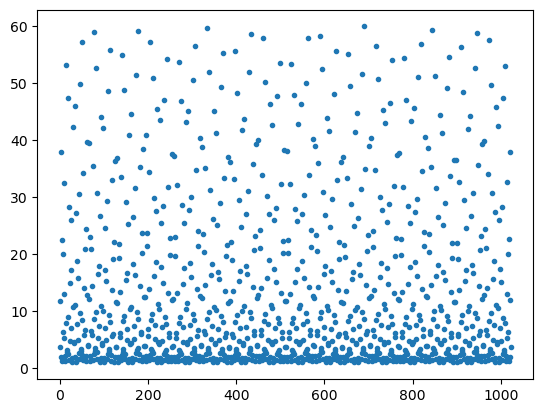

In [16]:
def transform_sample_vector(input_random_vector, low, high):
    """
    Transform a random vector from the unit hypercube to the specified range.
    
    Parameters:
    - input_random_vector: The random vector in the unit hypercube.
    - lower_bound: The lower bound of the desired range.
    - upper_bound: The upper bound of the desired range.
    
    Returns:
    - Transformed random vector in the specified range.
    """
    if low == 0 and high == 1:
        return input_random_vector
    return 10 ** (np.log10(low) + input_random_vector * (np.log10(high) - np.log10(low)))

new_vector = transform_sample_vector(sample[:, 0], config['search_space']['mu_M'][1], config['search_space']['mu_M'][2])

plt.plot(new_vector, '.')

In [17]:
# Create empty df that will get written to the csv 
df = pd.DataFrame()
for key in default_params.keys():
    df[key] = [default_params[key]]*n_points

In [18]:
for i, key in enumerate(config['search_space']):
    value, lower_bound, upper_bound = config['search_space'][key]
    df[key] = transform_sample_vector(sample[:, i], lower_bound, upper_bound)

In [19]:
df.to_csv("Generated_log_sobol_input.csv", index = False)


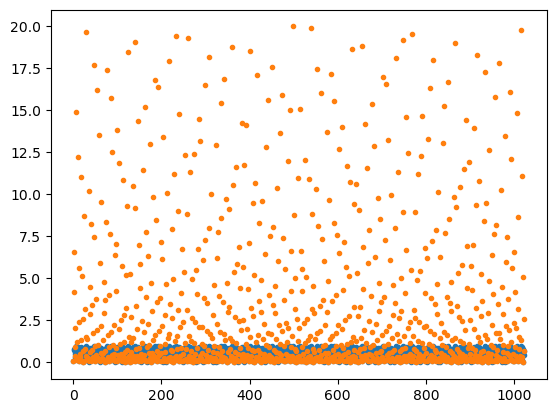

In [20]:
x = sample[:,i]
plt.plot(x,'.')



low = 0.05
high = 20
log_values = 10 ** (np.log10(low) + x * (np.log10(high) - np.log10(low)))

plt.plot(log_values, '.')